# Graphical Attention Network

### context:
University Karate Club: 
There was this Univeristy Karate club (total of 34 members) that have 2 leaders who do not like eachother. 

- Mr. Hi is the Karate instructor 
- John A. is the club president 

Both of them got into an arguement, which resulted in in the karate club members to split into 2 groups.

### Problem: 
Given only the friendship connections (the graph), can we predict which side each member choose when the club split?

### Load the dataset

In [9]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import networkx as nx

#load the karate club graph 
G = nx.karate_club_graph()

print("Number of nodes:", G.number_of_nodes()) # 34 members in the club
print("Number of edges:", G.number_of_edges()) # 78 friendships between members
print("Nodes:", G.nodes()) # List of members in the club
print("Edges:", G.edges()) # List of friendships (edges) between members

print()

print(G.nodes[0]) # To see the attributes of member 0

# To see the club affiliation of member 5
print(f"node: 5, club: {G.nodes[5]['club']}")

# To see the club affiliation of member 9
print(f"node: 9, club: {G.nodes[9]['club']}")

Number of nodes: 34
Number of edges: 78
Nodes: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33]
Edges: [(0, 1), (0, 2), (0, 3), (0, 4), (0, 5), (0, 6), (0, 7), (0, 8), (0, 10), (0, 11), (0, 12), (0, 13), (0, 17), (0, 19), (0, 21), (0, 31), (1, 2), (1, 3), (1, 7), (1, 13), (1, 17), (1, 19), (1, 21), (1, 30), (2, 3), (2, 7), (2, 8), (2, 9), (2, 13), (2, 27), (2, 28), (2, 32), (3, 7), (3, 12), (3, 13), (4, 6), (4, 10), (5, 6), (5, 10), (5, 16), (6, 16), (8, 30), (8, 32), (8, 33), (9, 33), (13, 33), (14, 32), (14, 33), (15, 32), (15, 33), (18, 32), (18, 33), (19, 33), (20, 32), (20, 33), (22, 32), (22, 33), (23, 25), (23, 27), (23, 29), (23, 32), (23, 33), (24, 25), (24, 27), (24, 31), (25, 31), (26, 29), (26, 33), (27, 33), (28, 31), (28, 33), (29, 32), (29, 33), (30, 32), (30, 33), (31, 32), (31, 33), (32, 33)]

{'club': 'Mr. Hi'}
node: 5, club: Mr. Hi
node: 9, club: Officer


Making the Adjacency Matrix

In [10]:
# the built in Adjacecy matrix aparaently keep track of how strong the connection is between two nodes, so it is not binary. 
A = nx.adjacency_matrix(G).toarray() 
print(A.shape)
print(A)

print()

print("Binary adjacency matrix:")
# Make the adjacency matrix binary (1 if there is a connection, 0 if there is not)
A_binary = (A > 0).astype(float)
print(A_binary)


(34, 34)
[[0 4 5 ... 2 0 0]
 [4 0 6 ... 0 0 0]
 [5 6 0 ... 0 2 0]
 ...
 [2 0 0 ... 0 4 4]
 [0 0 2 ... 4 0 5]
 [0 0 0 ... 4 5 0]]

Binary adjacency matrix:
[[0. 1. 1. ... 1. 0. 0.]
 [1. 0. 1. ... 0. 0. 0.]
 [1. 1. 0. ... 0. 1. 0.]
 ...
 [1. 0. 0. ... 0. 1. 1.]
 [0. 0. 1. ... 1. 0. 1.]
 [0. 0. 0. ... 1. 1. 0.]]


Getting the features and ready for the graph dataset

In [11]:
num_nodes = G.number_of_nodes()
print(f"Number of nodes: {num_nodes}")

# unfortunately, the karate club graph does not have any node features, so we will use an identity matrix as a placeholder for the node features. Each node will be represented by a one-hot vector indicating its identity.
X = np.eye(num_nodes) # Identity matrix as node features 
print(X.shape)
print(X)

# assigning labels to the nodes based on their club affiliation
labels = np.array([0 if G.nodes[i]['club'] == 'Mr. Hi' else 1 for i in G.nodes()])

print()
# Print the labels for each node
print(labels)

Number of nodes: 34
(34, 34)
[[1. 0. 0. ... 0. 0. 0.]
 [0. 1. 0. ... 0. 0. 0.]
 [0. 0. 1. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 1. 0. 0.]
 [0. 0. 0. ... 0. 1. 0.]
 [0. 0. 0. ... 0. 0. 1.]]

[0 0 0 0 0 0 0 0 0 1 0 0 0 0 1 1 0 0 1 0 1 0 1 1 1 1 1 1 1 1 1 1 1 1]


### Preparing the graph structure for attention

In [12]:
# Making self loops because in the GAT paper, they add self loops to the graph. This means that each node will also attend to itself when computing the attention scores. This allows the model to capture the importance of a node's own features in addition to the features of its neighbors.
# Editing the adjacency matrix to add self loops (i.e., set the diagonal to 1)
A_with_self_loops = A_binary + np.eye(num_nodes) # TLDR: Self loops makes it so that the nodes consider their own features when computing attention scores.
print(A_with_self_loops)

print()

# Edge list with self loops, so that if that we don't waste computing power on non-existent edges. This is important because in a GAT, we only compute attention scores for the edges that exist in the graph (including self loops), rather than for all possible pairs of nodes. This makes the model more efficient and focused on the relevant connections in the graph.
edges = np.array(np.where(A_with_self_loops > 0)).T #
print(f"Number of edges (with self-loops): {len(edges)}")
print("First 5 edges:", edges[:5])


# Convert everything to PyTorch tensors
X = torch.FloatTensor(X)
labels = torch.LongTensor(labels)
edges = torch.LongTensor(edges)
A_with_self_loops = torch.FloatTensor(A_with_self_loops)


[[1. 1. 1. ... 1. 0. 0.]
 [1. 1. 1. ... 0. 0. 0.]
 [1. 1. 1. ... 0. 1. 0.]
 ...
 [1. 0. 0. ... 1. 1. 1.]
 [0. 0. 1. ... 1. 1. 1.]
 [0. 0. 0. ... 1. 1. 1.]]

Number of edges (with self-loops): 190
First 5 edges: [[0 0]
 [0 1]
 [0 2]
 [0 3]
 [0 4]]


### Building a single attention head

In [13]:
class GATHead(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()
        self.W = nn.Parameter(torch.randn(in_features, out_features) * 0.1)
        self.a_self = nn.Parameter(torch.randn(out_features, 1) * 0.1)
        self.a_neighbor = nn.Parameter(torch.randn(out_features, 1) * 0.1)

    def forward(self, H, A_with_self_loops, edges):
        self_scores = H @ self.a_self
        neighbor_scores = H @ self.a_neighbor
        e = self_scores[edges[:, 0]] + neighbor_scores[edges[:, 1]]
        e = F.leaky_relu(e, 0.01)
        attention = torch.zeros_like(A_with_self_loops)
        for i in range(A_with_self_loops.shape[0]):
            neighbors = torch.where(A_with_self_loops[i] > 0)[0]
            edge_mask = edges[:, 0] == i
            scores = e[edge_mask].flatten()
            attention[i, neighbors] = torch.softmax(scores, dim=0)
        return attention

### Building a full GAT layer (multi-head)

In [14]:
class GAT(nn.Module):
    def __init__(self, in_features, hidden_features, num_classes, num_heads):
        super().__init__()
        # Layer 1
        self.heads1 = nn.ModuleList([
            GATHead(in_features, hidden_features) for _ in range(num_heads)
        ])
        self.W1 = nn.Parameter(torch.randn(in_features, hidden_features) * 0.1)
        
        # Layer 2
        self.heads2 = nn.ModuleList([
            GATHead(hidden_features * num_heads, num_classes) for _ in range(num_heads)
        ])
        self.W2 = nn.Parameter(torch.randn(hidden_features * num_heads, num_classes) * 0.1)

    def forward(self, X, A_with_self_loops, edges):
        # Layer 1: transform, attend, concatenate
        H1 = X @ self.W1
        attentions1 = [head(H1, A_with_self_loops, edges) for head in self.heads1]
        layer1_outs = [att @ H1 for att in attentions1]
        layer1_out = torch.cat(layer1_outs, dim=1)
        layer1_out = F.elu(layer1_out)
        
        # Layer 2: transform, attend, average
        H2 = layer1_out @ self.W2
        attentions2 = [head(H2, A_with_self_loops, edges) for head in self.heads2]
        layer2_outs = [att @ H2 for att in attentions2]
        layer2_out = torch.mean(torch.stack(layer2_outs), dim=0)
        
        return layer2_out

In [15]:
# Create model
model = GAT(in_features=34, hidden_features=8, num_classes=2, num_heads=3)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

print(model)

from torchinfo import summary
summary(model, input_data=(X, A_with_self_loops, edges))

GAT(
  (heads1): ModuleList(
    (0-2): 3 x GATHead()
  )
  (heads2): ModuleList(
    (0-2): 3 x GATHead()
  )
)


Layer (type:depth-idx)                   Output Shape              Param #
GAT                                      [34, 2]                   320
├─ModuleList: 1-1                        --                        --
│    └─GATHead: 2-1                      [34, 34]                  288
│    └─GATHead: 2-2                      [34, 34]                  288
│    └─GATHead: 2-3                      [34, 34]                  288
├─ModuleList: 1-2                        --                        --
│    └─GATHead: 2-4                      [34, 34]                  52
│    └─GATHead: 2-5                      [34, 34]                  52
│    └─GATHead: 2-6                      [34, 34]                  52
Total params: 1,340
Trainable params: 1,340
Non-trainable params: 0
Total mult-adds (M): 0
Input size (MB): 0.01
Forward/backward pass size (MB): 0.06
Params size (MB): 0.00
Estimated Total Size (MB): 0.07

### Train the Model

In [16]:

model = GAT(in_features=34, hidden_features=8, num_classes=2, num_heads=3)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

losses = []  # track losses

for epoch in range(200):
    model.train()
    optimizer.zero_grad()
    output = model(X, A_with_self_loops, edges)
    loss = F.cross_entropy(output, labels)
    loss.backward()
    optimizer.step()
    
    losses.append(loss.item())  # save each loss
    
    if epoch % 20 == 0:
        predictions = output.argmax(dim=1)
        accuracy = (predictions == labels).float().mean()
        print(f"Epoch {epoch}, Loss: {loss:.4f}, Accuracy: {accuracy:.4f}")

Epoch 0, Loss: 0.6907, Accuracy: 0.5294
Epoch 20, Loss: 0.2152, Accuracy: 0.9706
Epoch 40, Loss: 0.0305, Accuracy: 1.0000
Epoch 60, Loss: 0.0047, Accuracy: 1.0000
Epoch 80, Loss: 0.0024, Accuracy: 1.0000
Epoch 100, Loss: 0.0017, Accuracy: 1.0000
Epoch 120, Loss: 0.0013, Accuracy: 1.0000
Epoch 140, Loss: 0.0011, Accuracy: 1.0000
Epoch 160, Loss: 0.0009, Accuracy: 1.0000
Epoch 180, Loss: 0.0008, Accuracy: 1.0000


### Visualize results

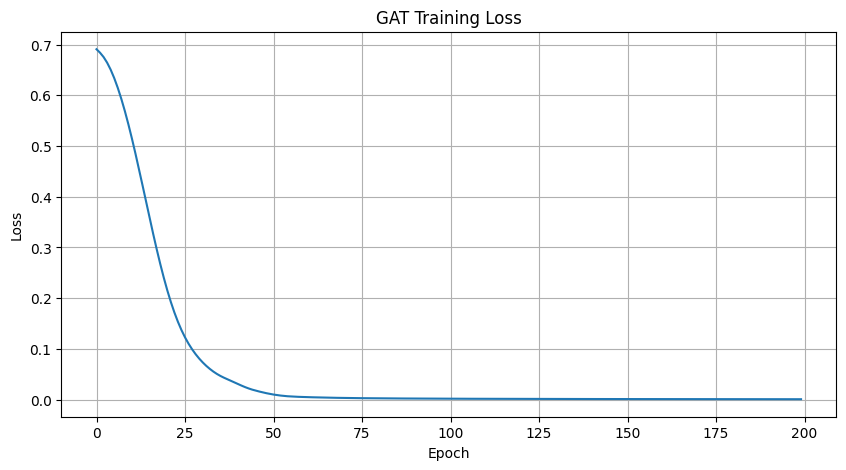

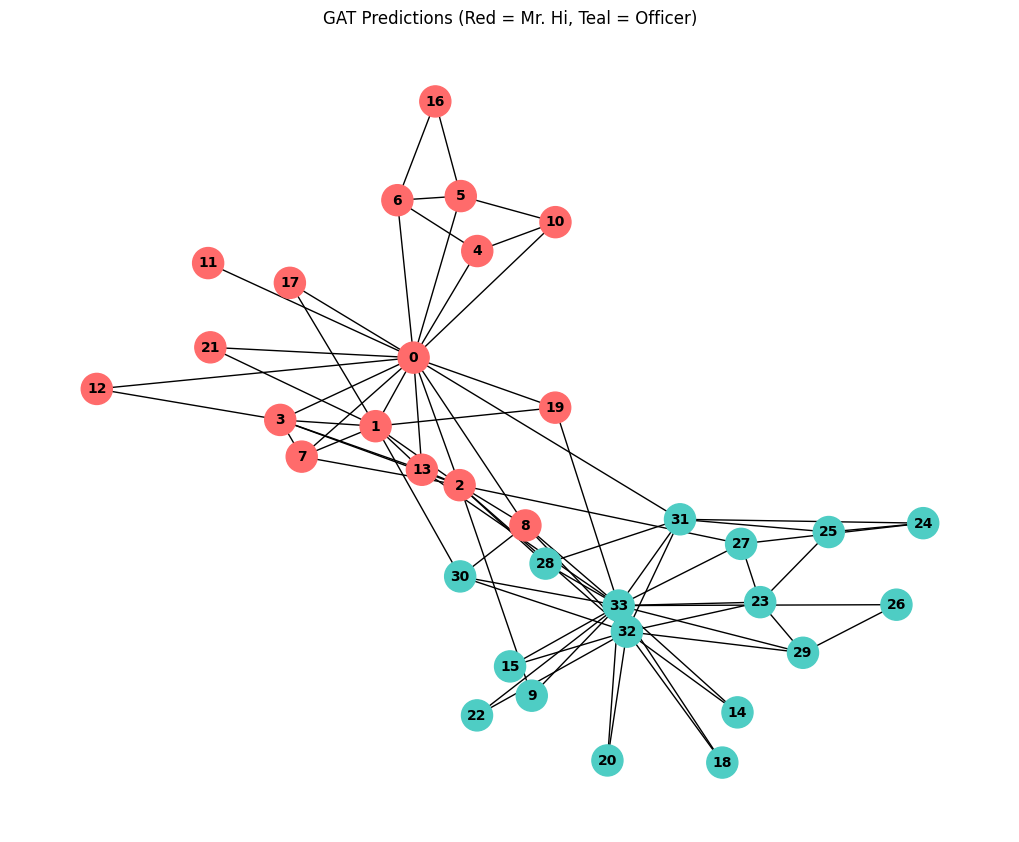

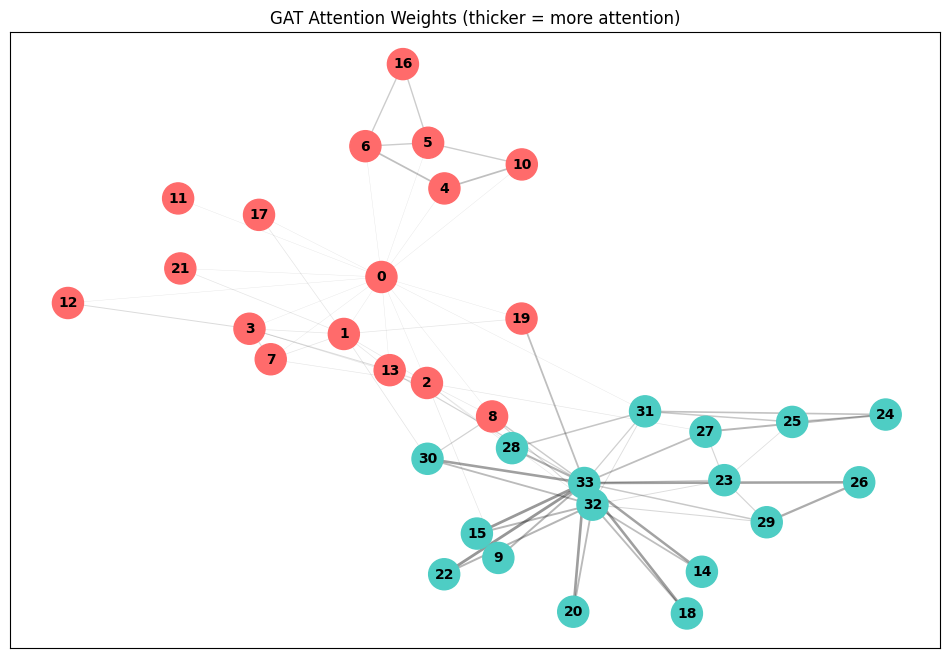

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('GAT Training Loss')
plt.grid(True)
plt.show()

model.eval()
with torch.no_grad():
    output = model(X, A_with_self_loops, edges)
    predictions = output.argmax(dim=1).numpy()

# Draw the graph with colored nodes
plt.figure(figsize=(10, 8))
pos = nx.spring_layout(G, seed=42)
colors = ['#FF6B6B' if p == 0 else '#4ECDC4' for p in predictions]
nx.draw(G, pos, node_color=colors, with_labels=True, 
        node_size=500, font_size=10, font_weight='bold')
plt.title('GAT Predictions (Red = Mr. Hi, Teal = Officer)')
plt.show()

model.eval()
with torch.no_grad():
    H1 = X @ model.W1
    # Get attention from first head of layer 1
    attention = model.heads1[0](H1, A_with_self_loops, edges)
    attention = attention.numpy()

plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G, seed=42)
colors = ['#FF6B6B' if l == 0 else '#4ECDC4' for l in labels.numpy()]

# Draw nodes
nx.draw_networkx_nodes(G, pos, node_color=colors, node_size=500)
nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold')

# Draw edges with width based on attention weights
for u, v in G.edges():
    weight = attention[u][v]
    nx.draw_networkx_edges(G, pos, edgelist=[(u, v)], 
                           width=weight * 5, alpha=max(weight, 0.1))

plt.title('GAT Attention Weights (thicker = more attention)')
plt.show()

## Experiment: leave a node out 

the above training, I trained on 100% of the data. And beacause of that the model has overfitted the data. 

Since this is a smaller dataset. I can't really have a good split on the data. What if I tried to leave one node out. Like it would still be connected in the graph, But its label is hidden from the model during training. 

The Model can still see the node from the graph's structure, but it just doesn't know its label. 

In [30]:
correct = 0
wrong_nodes = []

# Loop through all the nodes, and have each node take turn to be hidden and see what the model predicts. See if the neighbor relationship help with the prediction
for test_node in range(num_nodes):
    model = GAT(in_features=34, hidden_features=8, num_classes=2, num_heads=3)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

    # set all nodes to be true 
    train_mask = torch.ones(num_nodes, dtype=torch.bool)
    # set the current node as false so that it is hidden during training
    train_mask[test_node] = False

    for epoch in range(200):
        model.train()
        optimizer.zero_grad()
        output = model(X, A_with_self_loops, edges)
        # Only compute loss on the training nodes (excluding the test node)
        loss = F.cross_entropy(output[train_mask], labels[train_mask])
        loss.backward()
        optimizer.step()

    model.eval()
    with torch.no_grad():
        output = model(X, A_with_self_loops, edges)
        prediction = output[test_node].argmax().item()
        if prediction == labels[test_node].item():
            correct += 1

        else:
            wrong_nodes.append(test_node)

accuracy = correct / num_nodes
print(f"Leave-One-Out Accuracy: {accuracy:.4f} ({correct}/{num_nodes})")
print(f"Wrong nodes: {wrong_nodes}")



Leave-One-Out Accuracy: 0.9412 (32/34)
Wrong nodes: [8, 30]


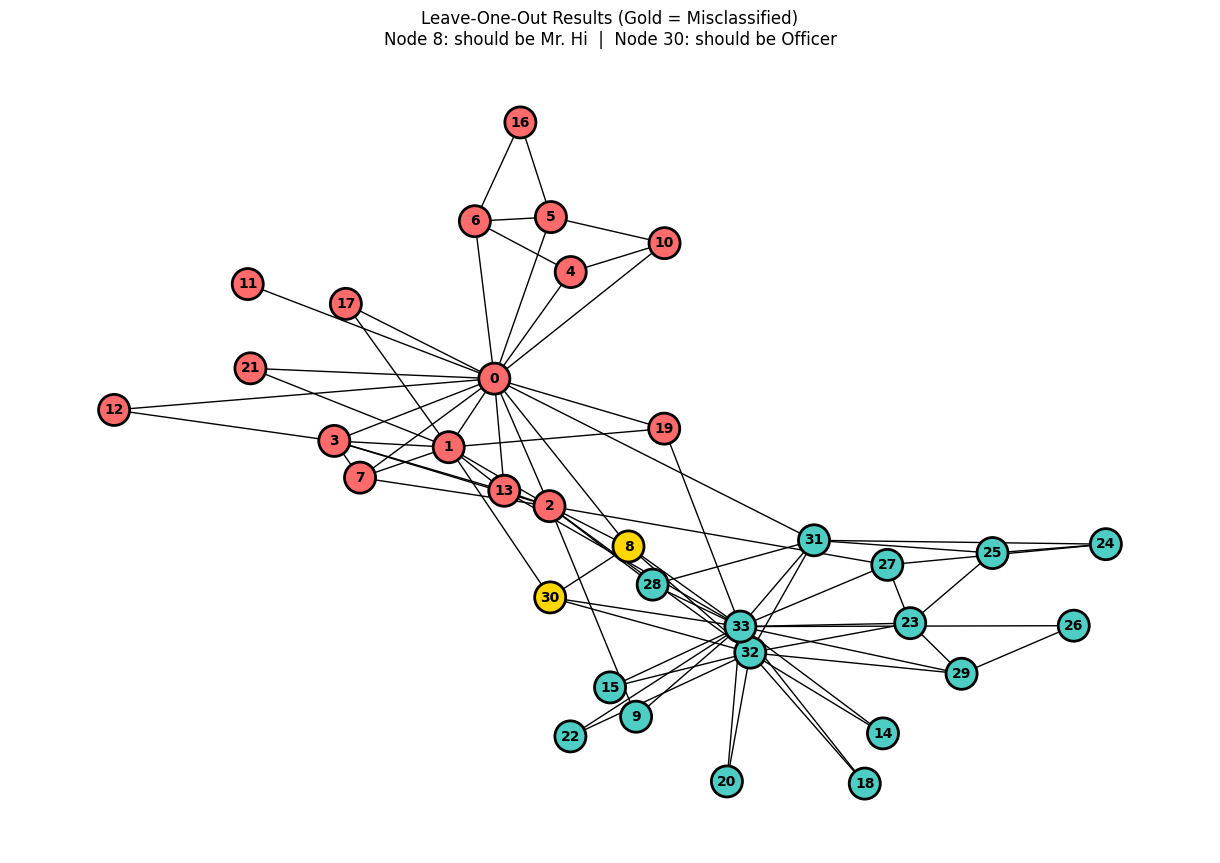

In [31]:
plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G, seed=42)

# Color nodes: wrong ones get a special color
node_colors = []
for i in range(num_nodes):
    if i in wrong_nodes:
        node_colors.append('#FFD700')  # Gold for wrong predictions
    elif labels[i] == 0:
        node_colors.append('#FF6B6B')  # Red for Mr. Hi
    else:
        node_colors.append('#4ECDC4')  # Teal for Officer

nx.draw(G, pos, node_color=node_colors, with_labels=True,
        node_size=500, font_size=10, font_weight='bold',
        edgecolors='black', linewidths=2)

# Build description of wrong nodes
wrong_info = []
for node in wrong_nodes:
    true_label = "Mr. Hi" if labels[node] == 0 else "Officer"
    wrong_info.append(f"Node {node}: should be {true_label}")

plt.title('Leave-One-Out Results (Gold = Misclassified)\n' + '  |  '.join(wrong_info))
plt.show()

In [32]:
for node in wrong_nodes:
    true_label = "Mr. Hi" if labels[node] == 0 else "Officer"
    neighbors = list(G.neighbors(node))
    neighbor_labels = [("Mr. Hi" if labels[n] == 0 else "Officer") for n in neighbors]
    print(f"Node {node} (true: {true_label})")
    print(f"  Neighbors: {neighbors}")
    print(f"  Neighbor clubs: {neighbor_labels}")

Node 8 (true: Mr. Hi)
  Neighbors: [0, 2, 30, 32, 33]
  Neighbor clubs: ['Mr. Hi', 'Mr. Hi', 'Officer', 'Officer', 'Officer']
Node 30 (true: Officer)
  Neighbors: [1, 8, 32, 33]
  Neighbor clubs: ['Mr. Hi', 'Mr. Hi', 'Officer', 'Officer']


### Using Graphical Attention Network with CORA (LARGER DATABASE):

The Cora dataset is a citation network of 2,708 machine learning papers. Each paper (node) is connected to other papers it cites (edges), creating a graph of 5,429 links. Each paper belongs to one of 7 research categories: Case Based, Genetic Algorithms, Neural Networks, Probabilistic Methods, Reinforcement Learning, Rule Learning, and Theory.


The features: each paper has a 1,433-dimension feature vector representing which words appear in the paper. This is a big deal because unlike Karate Club where we had to use one-hot encoding, Cora has real features.

### Task: Predict which category each paper belongs to based on the citation graph and word features

In [33]:
! pip install torch_geometric

Defaulting to user installation because normal site-packages is not writeable


In [34]:
from torch_geometric.datasets import Planetoid

dataset = Planetoid(root='./data', name='Cora')
data = dataset[0]

print(f"Nodes: {data.num_nodes}")
print(f"Edges: {data.num_edges}")
print(f"Features per node: {data.num_node_features}")
print(f"Classes: {dataset.num_classes}")
print(f"Training nodes: {data.train_mask.sum().item()}")
print(f"Validation nodes: {data.val_mask.sum().item()}")
print(f"Test nodes: {data.test_mask.sum().item()}")

/home/eric/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Nodes: 2708
Edges: 10556
Features per node: 1433
Classes: 7
Training nodes: 140
Validation nodes: 500
Test nodes: 1000


Processing...
Done!


In [39]:
from torch_geometric.nn import GATConv

class CoraGAT(nn.Module):
    def __init__(self, in_features, hidden_features, num_classes, num_heads, dropout=0.6):
        super().__init__()
        self.dropout = dropout
        self.gat1 = GATConv(in_features, hidden_features, heads=num_heads, dropout=dropout)
        self.gat2 = GATConv(hidden_features * num_heads, num_classes, heads=1, dropout=dropout)
    
    def forward(self, x, edge_index):
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.gat1(x, edge_index)
        x = F.elu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.gat2(x, edge_index)
        return x

Training Loop

In [40]:
model = CoraGAT(in_features=1433, hidden_features=8, num_classes=7, num_heads=8)
optimizer = torch.optim.Adam(model.parameters(), lr=0.005, weight_decay=5e-4)

In [49]:
losses = []
val_accs = []
train_accs = []

for epoch in range(200):
    model.train()
    optimizer.zero_grad()
    output = model(data.x, data.edge_index)
    loss = F.cross_entropy(output[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()
    
    losses.append(loss.item())
    
    
    model.eval()
    with torch.no_grad():
        output = model(data.x, data.edge_index)
        # Grab only the training nodes prediction and pick which ever class has the highest score as the predicted class
        train_pred = output[data.train_mask].argmax(dim=1)
        # Grab only the validation nodes prediction and pick which ever class has the highest score as the predicted class
        val_pred = output[data.val_mask].argmax(dim=1)
        # Calculate the training accuracy by comparing the predicted classes to the true labels for the training nodes, and take the mean to get the overall accuracy
        train_accs.append((train_pred == data.y[data.train_mask]).float().mean().item())
        val_accs.append((val_pred == data.y[data.val_mask]).float().mean().item())

    if epoch % 20 == 0:
        print(f"Epoch {epoch}, Loss: {loss:.4f}, Train Acc: {train_accs[-1]:.4f}, Val Acc: {val_accs[-1]:.4f}")

Epoch 0, Loss: 0.4573, Train Acc: 1.0000, Val Acc: 0.7760
Epoch 20, Loss: 0.3113, Train Acc: 1.0000, Val Acc: 0.7800
Epoch 40, Loss: 0.3490, Train Acc: 0.9929, Val Acc: 0.7760
Epoch 60, Loss: 0.4238, Train Acc: 1.0000, Val Acc: 0.7620
Epoch 80, Loss: 0.2501, Train Acc: 1.0000, Val Acc: 0.7740
Epoch 100, Loss: 0.3017, Train Acc: 1.0000, Val Acc: 0.7740
Epoch 120, Loss: 0.2786, Train Acc: 1.0000, Val Acc: 0.7720
Epoch 140, Loss: 0.3054, Train Acc: 1.0000, Val Acc: 0.7700
Epoch 160, Loss: 0.4741, Train Acc: 1.0000, Val Acc: 0.7760
Epoch 180, Loss: 0.3194, Train Acc: 1.0000, Val Acc: 0.7800


Evaluate

In [52]:
model.eval()
with torch.no_grad():
    output = model(data.x, data.edge_index)
    test_pred = output[data.test_mask].argmax(dim=1)
    test_acc = (test_pred == data.y[data.test_mask]).float().mean()
    print(f"Test Accuracy: {test_acc:.4f} ({test_pred.eq(data.y[data.test_mask]).sum().item()}/{data.test_mask.sum().item()})")

Test Accuracy: 0.7900 (790/1000)


T-SNE for 2D visualization of the different classes

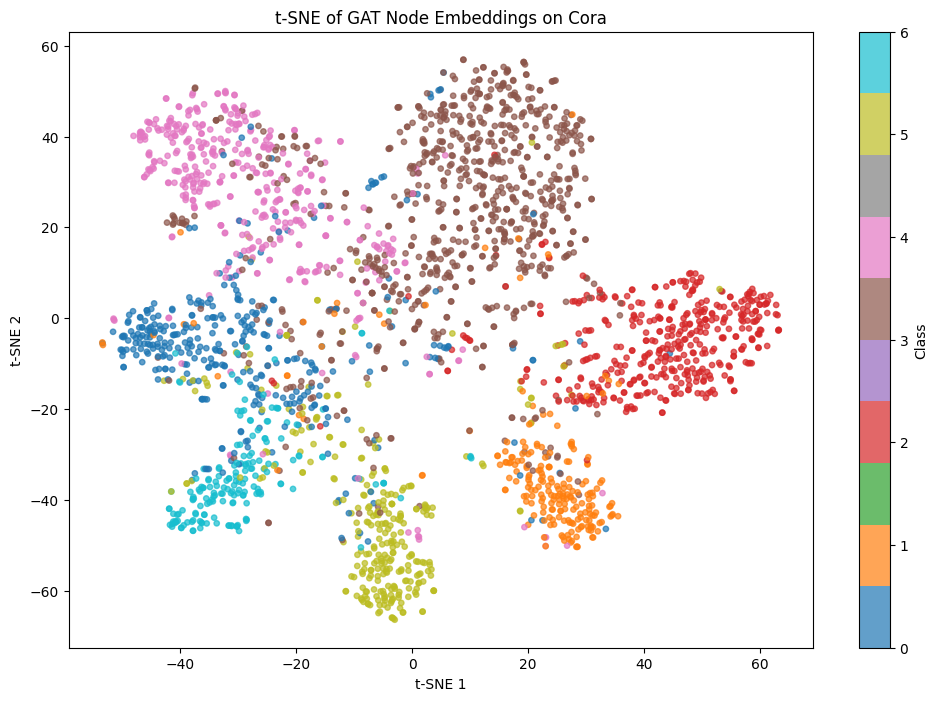

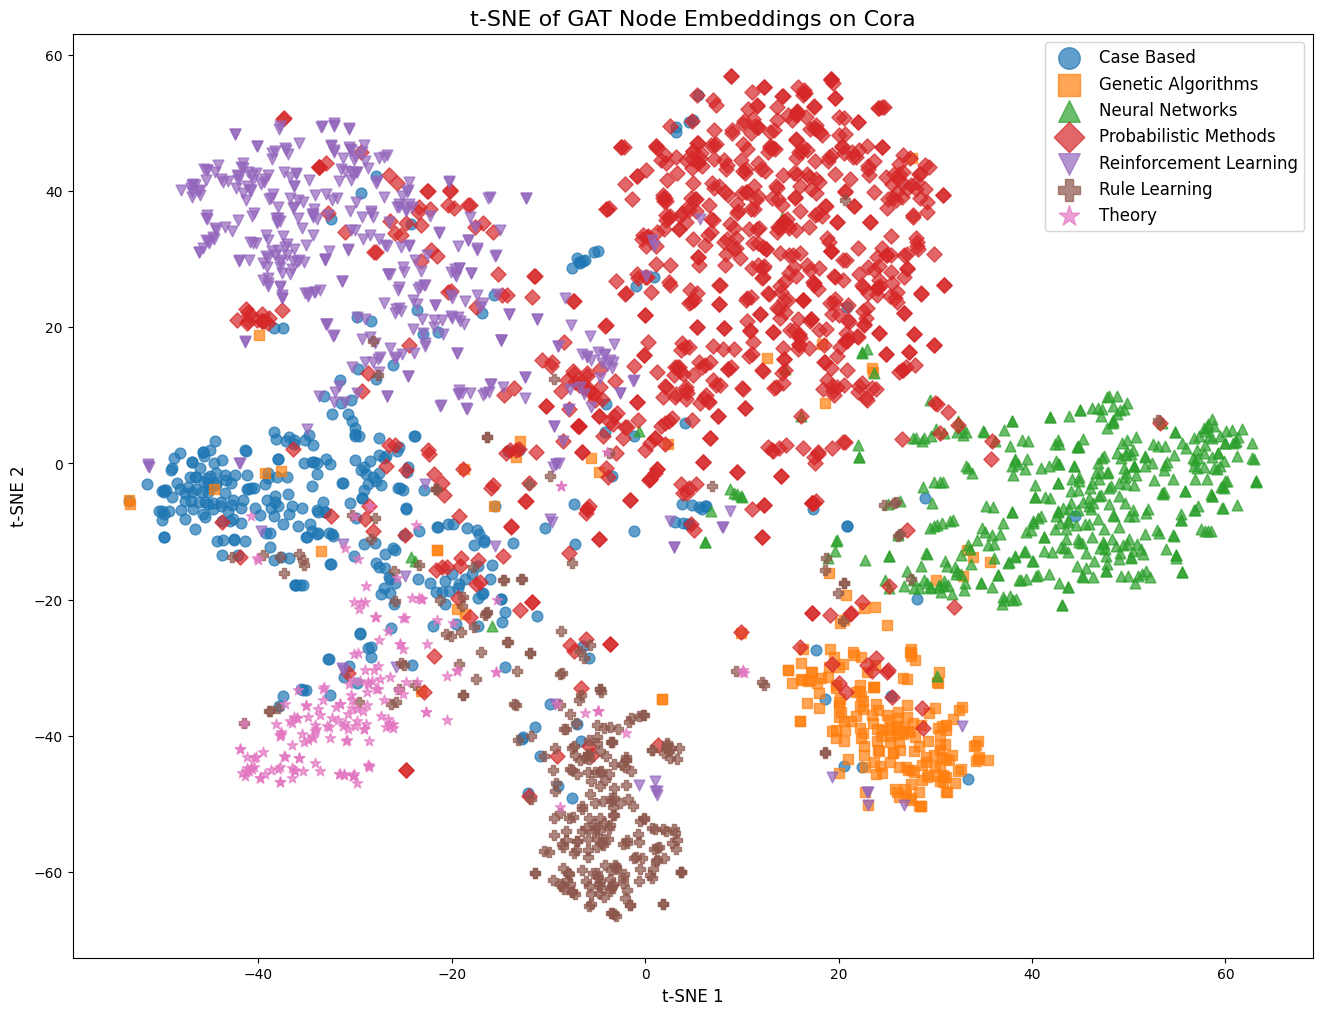

In [54]:
from sklearn.manifold import TSNE

model.eval()
with torch.no_grad():
    # Get embeddings from layer 1 (before final classification)
    x = F.dropout(data.x, p=0.6, training=False)
    embeddings = model.gat1(x, data.edge_index)
    embeddings = F.elu(embeddings)
    embeddings = embeddings.numpy()

# Reduce to 2D with t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
embeddings_2d = tsne.fit_transform(embeddings)

# Plot
plt.figure(figsize=(12, 8))
scatter = plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], 
                      c=data.y.numpy(), cmap='tab10', s=15, alpha=0.7)
plt.colorbar(scatter, label='Class')
plt.title('t-SNE of GAT Node Embeddings on Cora')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.show()

class_names = ['Case Based', 'Genetic Algorithms', 'Neural Networks', 
               'Probabilistic Methods', 'Reinforcement Learning', 
               'Rule Learning', 'Theory']
markers = ['o', 's', '^', 'D', 'v', 'P', '*']

plt.figure(figsize=(16, 12))
for i, name in enumerate(class_names):
    mask = data.y.numpy() == i
    plt.scatter(embeddings_2d[mask, 0], embeddings_2d[mask, 1], 
                s=60, alpha=0.7, label=name, marker=markers[i])

plt.legend(markerscale=2, fontsize=12)
plt.title('t-SNE of GAT Node Embeddings on Cora', fontsize=16)
plt.xlabel('t-SNE 1', fontsize=12)
plt.ylabel('t-SNE 2', fontsize=12)
plt.show()

Training accuracy and Validation accuaracy flatten

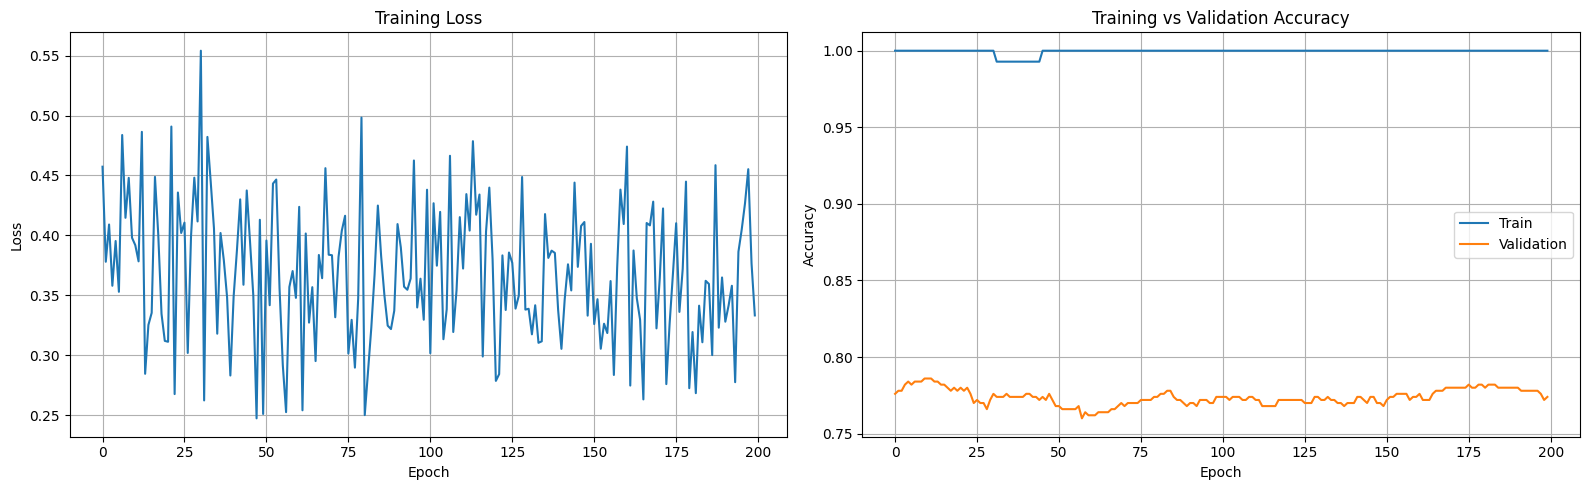

In [55]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 1. Training loss curve
axes[0].plot(losses)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training Loss')
axes[0].grid(True)

# 2. Training vs Validation accuracy
axes[1].plot(train_accs, label='Train')
axes[1].plot(val_accs, label='Validation')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Training vs Validation Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

Confusion Matrix

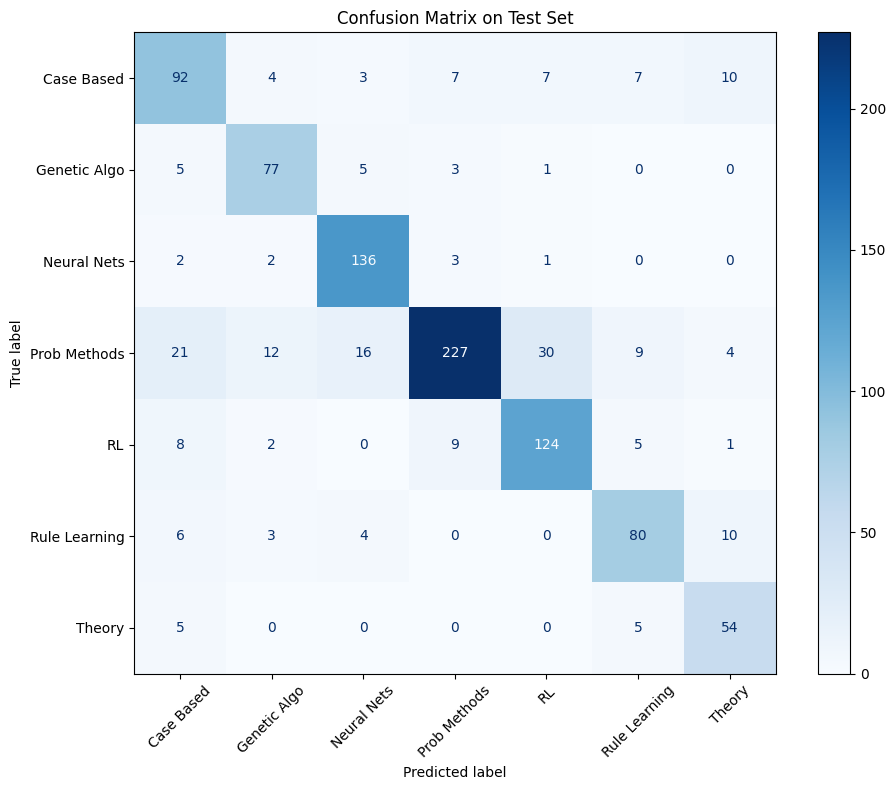

In [56]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

model.eval()
with torch.no_grad():
    output = model(data.x, data.edge_index)
    test_pred = output[data.test_mask].argmax(dim=1).numpy()
    test_true = data.y[data.test_mask].numpy()

class_names = ['Case Based', 'Genetic Algo', 'Neural Nets', 
               'Prob Methods', 'RL', 'Rule Learning', 'Theory']

cm = confusion_matrix(test_true, test_pred)
fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
disp.plot(ax=ax, cmap='Blues', xticks_rotation=45)
plt.title('Confusion Matrix on Test Set')
plt.tight_layout()
plt.show()

Per class accuracy

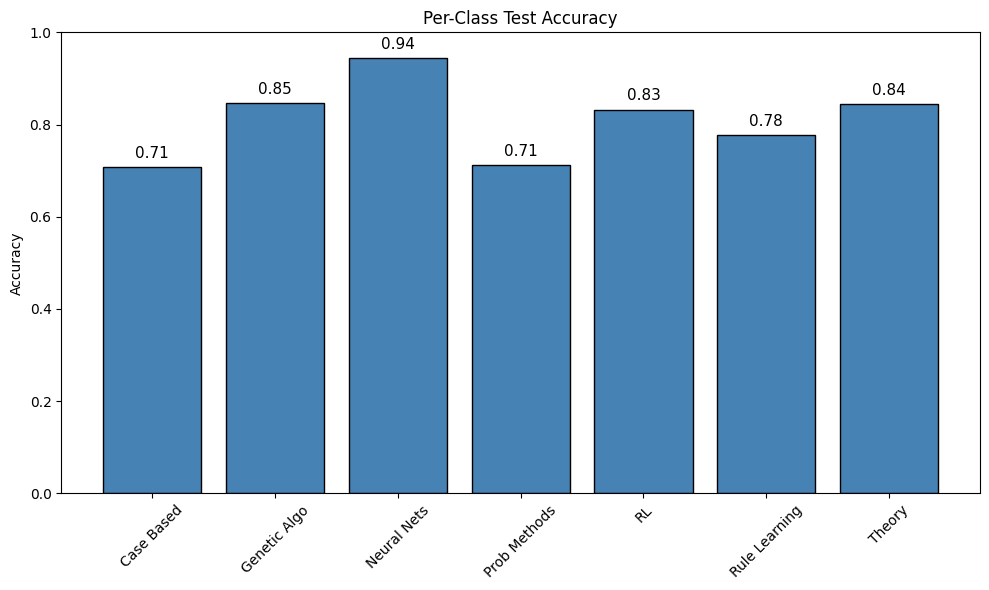

In [57]:
class_names = ['Case Based', 'Genetic Algo', 'Neural Nets', 
               'Prob Methods', 'RL', 'Rule Learning', 'Theory']

per_class_acc = cm.diagonal() / cm.sum(axis=1)

plt.figure(figsize=(10, 6))
bars = plt.bar(class_names, per_class_acc, color='steelblue', edgecolor='black')
plt.ylabel('Accuracy')
plt.title('Per-Class Test Accuracy')
plt.xticks(rotation=45)
plt.ylim(0, 1.0)

for bar, acc in zip(bars, per_class_acc):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
             f'{acc:.2f}', ha='center', fontsize=11)

plt.tight_layout()
plt.show()

# References:
1) https://networkx.org/documentation/stable/tutorial.html
2) https://networkx.org/documentation/stable/reference/generated/networkx.generators.social.karate_club_graph.html
3) https://networkx.org/documentation/stable/reference/generated/networkx.linalg.graphmatrix.adjacency_matrix.html
4) https://numpy.org/devdocs/reference/generated/numpy.where.html
5) https://docs.pytorch.org/docs/stable/generated/torch.nn.parameter.Parameter.html
6) https://docs.pytorch.org/docs/stable/generated/torch.nn.ModuleList.html
7) https://docs.pytorch.org/docs/stable/generated/torch.numel.html
8) https://pytorch-geometric.readthedocs.io/en/2.5.0/generated/torch_geometric.datasets.Planetoid.html
9) https://pytorch-geometric.readthedocs.io/en/2.5.1/generated/torch_geometric.nn.conv.GATConv.html